# CDSDS 542 Sp2026 - Discussion 8: CNN

[![](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/DL4DS/fa2026_discussions/blob/main/discussion_08.ipynb)

####  Computer vision libraries in PyTorch

| PyTorch module | What does it do? |
| ----- | ----- |
| [`torchvision`](https://pytorch.org/vision/stable/index.html) | Contains datasets, model architectures and image transformations often used for computer vision problems. |
| [`torchvision.datasets`](https://pytorch.org/vision/stable/datasets.html) | Here you'll find many example computer vision datasets for a range of problems from image classification, object detection, image captioning, video classification and more. It also contains [a series of base classes for making custom datasets](https://pytorch.org/vision/stable/datasets.html#base-classes-for-custom-datasets). |
| [`torchvision.models`](https://pytorch.org/vision/stable/models.html) | This module contains well-performing and commonly used computer vision model architectures implemented in PyTorch, you can use these with your own problems. |
| [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) | Often images need to be transformed (turned into numbers/processed/augmented) before being used with a model, common image transformations are found here. |
| [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) | Base dataset class for PyTorch.  |
| [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#module-torch.utils.data) | Creates a Python iterable over a dataset (created with `torch.utils.data.Dataset`). |    
    

In [16]:
!pip install pycocotools -q

In [17]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from io import BytesIO
import numpy as np
import requests

from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
from pycocotools.coco import COCO

### **Exercise 1 — Basic Output Size**

A 1D convolution layer has:

* Input: 1 channel, length (6)
* Kernel size: (3)
* Stride: (1)
* Padding: (0)
* Number of output channels: (2)

**(a)** How many output values does each output channel produce?

**(b)** If channel-1’s kernel is $(w_1,w_2,w_3)$ and inputs are $x_1,\dots,x_6$, write the formula for the first output value $h_1^{(1)}$ of channel 1?


**Solution**:







---

### **Exercise 2 — Parameter Count**

A 2D convolution layer takes:

* Input: 3 channels, RGB
* Output: 16 channels
* Kernel size: $3\times3$
* Bias term per **output channel**.

Find the total number of learnable parameters (including biases).
(Hint: each output channel has 3×3×3 = 27 weights + 1 bias)

**Solution**:









---


![example of going through the different parameters of a Conv2d layer](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/03-conv2d-layer.gif)

*Example of what happens when you change the hyperparameters of a `nn.Conv2d()` layer.*
![title](https://ujwlkarn.files.wordpress.com/2016/07/convolution_schematic.gif)

#### Typical CNN framework
![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-4-59-29-pm.png)


In Practice a CNN will learn the values of these filters on its own, during the training process. We need to define the parameters of `nn.Conv2d()`:

* `in_channels` (int) - Number of channels in the input image.
* `out_channels` (int) - Number of channels produced by the convolution. (Number of filters)
* `kernel_size` (int or tuple) - Size of the convolving kernel/filter.
* `stride` (int or tuple, optional) - How big of a step the convolving kernel takes at a time. Default: 1.
* `padding` (int, tuple, str) - Padding added to all four sides of input. We can add extra pixels around the edges of the input image to make sure the filter properly passes over the edges of the image. A feature of zero padding is that it will allow us to control the spatial size of the output volumes. Used when its required to preserve the spatial size of the input volume so the input and output width and height are the same. Default: 0.

### Convolution Layers

In [48]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
tensor = torch.randn(1, 3, 64, 64)
output = conv_layer(tensor)
print(conv_layer)
print(output.size())
print()

conv_layer_2 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=4, stride=2, padding=1)
output_2 = conv_layer_2(tensor)
print(conv_layer_2)
print(output_2.size())

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
torch.Size([1, 16, 64, 64])

Conv2d(3, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
torch.Size([1, 16, 32, 32])


### Pooling Layers

Pooling layer downsamples the volume spatially, independently in each depth slice of the input volume. Left: In this example, the input volume of size [224x224x64] is pooled with filter size 2, stride 2 into output volume of size [112x112x64]. Notice that the volume depth is preserved. Right: The most common downsampling operation is max, giving rise to max pooling, here shown with a stride of 2. That is, each max is taken over 4 numbers (little 2x2 square).
![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-10-at-3-38-39-am.png?w=988)

In [49]:
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
output_3 = max_pool_layer(tensor)
print(tensor.shape)
print(max_pool_layer)
print(output_3.size())

torch.Size([1, 3, 64, 64])
MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
torch.Size([1, 3, 32, 32])


The function of Pooling is to progressively reduce the spatial size of the input representation.
* It reduces the amount of parameters and computation in the network, and hence to also control overfitting.
* It makes the detection of features invariant to small transformations, distortions and translations. (a small distortion in input will not change the output of Pooling – since we take the maximum / average value in a local neighborhood).
![title](https://ujwlkarn.files.wordpress.com/2016/08/screen-shot-2016-08-07-at-6-11-53-pm.png)

### Build a Simple CNN

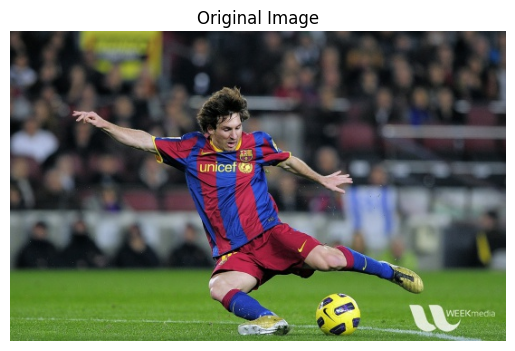

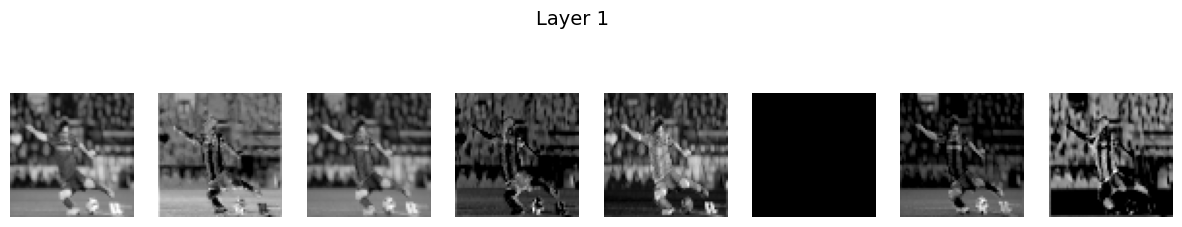

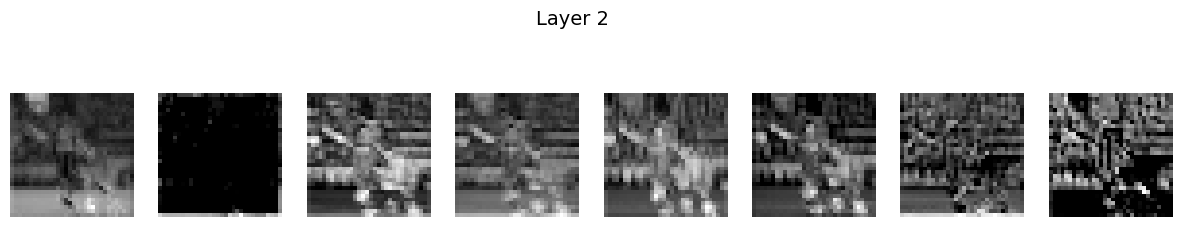

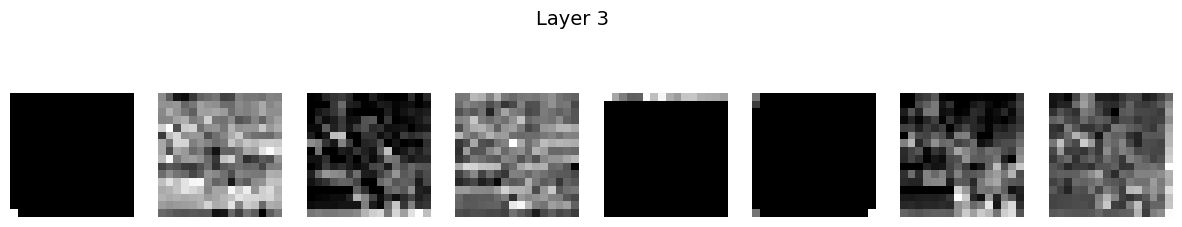

In [50]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        out1 = self.layer1(x)
        out2 = self.layer2(out1)
        out3 = self.layer3(out2)
        return out1, out2, out3

# load sample image
response = requests.get("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/messi5.jpg")
img = PILImage.open(BytesIO(response.content)).convert("RGB")
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])
x = transform(img).unsqueeze(0)

# forward pass
model = SimpleCNN()
with torch.no_grad():
    out1, out2, out3 = model(x)

# visualize layer outputs
def visualize(tensor, title, n=8):
    tensor = tensor.squeeze(0)
    tensor = tensor.detach().cpu().numpy()
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    fig.suptitle(title, fontsize=14)
    for i in range(n):
        axes[i].imshow(tensor[i], cmap='gray')
        axes[i].axis('off')
    plt.show()


plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()
visualize(out1, "Layer 1")
visualize(out2, "Layer 2")
visualize(out3, "Layer 3")


## **Exercise 3: Train an Object Detection Model**

Fill in the necessary blanks to complete the creation of a small object detection model. Then upload a picture of yourself to test it out!

We download the **COCO 2017 validation images (`val2017`)** and the **COCO annotations file**. In this exercise, we use the validation split instead of the training split so the dataset is smaller and faster to work with, while still giving us real labeled object detection data.

The annotations file contains the object categories and bounding boxes for each image, and the image folder contains the actual validation images.

In [19]:
download_file("http://images.cocodataset.org/zips/val2017.zip", "val2017.zip")
download_file("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", "annotations_trainval2017.zip")

import zipfile

if not os.path.exists("val2017"):
    with zipfile.ZipFile("val2017.zip", "r") as z:
        z.extractall(".")

if not os.path.exists("annotations"):
    with zipfile.ZipFile("annotations_trainval2017.zip", "r") as z:
        z.extractall(".")

We define the three object classes we want the detector to recognize: **person, car, and dog**. These are a small subset of the full COCO label space.

We also map the original COCO category IDs to our own model labels:
- COCO person → model class 0  
- COCO car → model class 1  
- COCO dog → model class 2  

This lets the model focus only on these three categories instead of all COCO classes.

### **Part One:** Fill in the category IDs

In [20]:
CLASS_NAMES = ["person", "car", "dog"]

# TODO: List o COCO category IDs:
# person = 1, car = 3, dog = 18
COCO_CAT_IDS = __FILL__

COCO_TO_MODEL = {1: 0, 3: 1, 18: 2}
MODEL_TO_NAME = {0: "person", 1: "car", 2: "dog"}

NUM_CLASSES = len(CLASS_NAMES)

We create a custom dataset that reads images and annotations from the **COCO validation set** and keeps only images that contain at least one of our target classes: **person, car, or dog**.

We resize every image to **128×128** and convert it to a tensor so it can be passed into the model. We also filter the image list so we only keep examples with valid bounding boxes, then stop once we reach the requested maximum number of images. This gives us a much smaller object detection dataset that is easier to train on than the full COCO set.

In [21]:
class COCOMiniYOLODataset(Dataset):
    def __init__(
        self,
        image_dir,
        annotation_file,
        class_ids,
        class_map,
        image_size=(128, 128),
        max_images=1000,
        min_box_area=0.0005,
        seed=42
    ):
        self.image_dir = image_dir
        self.coco = COCO(annotation_file)
        self.class_ids = class_ids
        self.class_map = class_map
        self.image_size = image_size
        self.min_box_area = min_box_area

        self.transform = T.Compose([
            T.Resize(image_size),
            T.ToTensor()
        ])

        # find all images containing at least one target class
        img_ids = set()
        for cat_id in class_ids:
            ids = self.coco.getImgIds(catIds=[cat_id])
            img_ids.update(ids)

        img_ids = list(img_ids)
        random.seed(seed)
        random.shuffle(img_ids)

        filtered_ids = []
        for img_id in img_ids:
            ann_ids = self.coco.getAnnIds(imgIds=[img_id], catIds=class_ids, iscrowd=False)
            anns = self.coco.loadAnns(ann_ids)

            valid = False
            for ann in anns:
                x, y, w, h = ann["bbox"]
                area_frac = (w * h) / (ann.get("width", w) * ann.get("height", h) + 1e-6)
                if w > 1 and h > 1:
                    valid = True
                    break

            if valid:
                filtered_ids.append(img_id)

            if len(filtered_ids) >= max_images:
                break

        self.image_ids = filtered_ids
        print(f"Loaded {len(self.image_ids)} images from {annotation_file}")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]

        file_name = img_info["file_name"]
        img_path = os.path.join(self.image_dir, file_name)

        img = PILImage.open(img_path).convert("RGB")
        orig_w, orig_h = img.size

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], catIds=self.class_ids, iscrowd=False)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []

        for ann in anns:
            coco_cat_id = ann["category_id"]
            if coco_cat_id not in self.class_map:
                continue

            x, y, w, h = ann["bbox"]

            if w <= 1 or h <= 1:
                continue

            # normalize to [0,1]
            x_center = (x + w / 2) / orig_w
            y_center = (y + h / 2) / orig_h
            bw = w / orig_w
            bh = h / orig_h

            if bw * bh < self.min_box_area:
                continue

            boxes.append([x_center, y_center, bw, bh])
            labels.append(self.class_map[coco_cat_id])

        if len(boxes) == 0:
            # fallback dummy target
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)

        img_tensor = self.transform(img)

        target = {
            "boxes": boxes,     # [N, 4] in normalized xywh
            "labels": labels    # [N]
        }

        return img_tensor, target

We build two datasets from the **same COCO validation annotations file (`instances_val2017.json`)**: one for training and one for validation.

Both datasets only use COCO validation images, but we create separate subsets by limiting the number of images:
- up to **800 images** for training
- up to **200 images** for validation

We also keep the input size at **128×128**, which matches the image size expected by our small YOLO-style detector.

### **Part Two:** Fill in the image **size**

In [23]:
import random
# TODO: Images should be 128x128
train_dataset = COCOMiniYOLODataset(
    image_dir="val2017",
    annotation_file="annotations/instances_val2017.json",
    class_ids=COCO_CAT_IDS,
    class_map=COCO_TO_MODEL,
    image_size=(__FILL__),
    max_images=800
)

val_dataset = COCOMiniYOLODataset(
    image_dir="val2017",
    annotation_file="annotations/instances_val2017.json",
    class_ids=COCO_CAT_IDS,
    class_map=COCO_TO_MODEL,
    image_size=(__FILL__),
    max_images=200
)

loading annotations into memory...
Done (t=0.51s)
creating index...
index created!
Loaded 800 images from annotations/instances_val2017.json
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
Loaded 200 images from annotations/instances_val2017.json


We define a custom collate function for batching object detection data. Unlike standard classification tasks, each image can have a different number of bounding boxes, so the targets cannot be stacked into one fixed tensor directly.

We stack the image tensors into a batch, but keep the annotations as a list of target dictionaries so each image can preserve its own set of boxes and labels.

In [24]:
def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images, dim=0)
    return images, list(targets)

We create the training and validation data loaders using a batch size of **8**. The training loader shuffles the data so the model sees images in a different order each epoch, while the validation loader does not shuffle because it is only used for evaluation.

These loaders let us iterate over batches of COCO images together with their bounding-box annotations during training and validation.

### **Part Three:** Complete the dataloaders for train and val

In [25]:
# TODO: Complete the train and val data loaders, use a batch size of 8

train_loader = DataLoader(__FILL__, batch_size=__FILL__, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(__FILL__, batch_size=__FILL__, shuffle=False, collate_fn=collate_fn)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 100
Val batches: 25


We define a small YOLO-style object detector. The convolutional backbone extracts visual features from the input image, and repeated max-pooling layers reduce the spatial resolution while increasing the depth of the feature maps.

After the feature extractor, we use adaptive pooling to produce an **8×8 grid**. For each grid cell, the final prediction head outputs:
- **1 objectness score**
- **4 box values** for the predicted bounding box
- **3 class scores** for person, car, and dog

So the model predicts object presence, location, and class for every cell in the grid.

In [26]:
class MiniYOLO(nn.Module):
    def __init__(self, num_classes=3, grid_size=8):
        super().__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
        )

        self.pool = nn.AdaptiveAvgPool2d((grid_size, grid_size))

        self.head = nn.Conv2d(
            256,
            1 + 4 + num_classes,
            kernel_size=1
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)              # [B, 1+4+C, S, S]
        x = x.permute(0, 2, 3, 1)     # [B, S, S, 1+4+C]
        return x

We convert the COCO bounding box annotations into the target format used by our YOLO-style model. For each object, we determine which **8×8 grid cell** contains the box center and store the target information in that cell.

Each active cell stores:
- whether an object is present
- the box center offsets within the cell
- the box width and height
- a one-hot class label for person, car, or dog

This turns the original COCO annotations into a grid-based representation that matches the model output shape.

In [27]:
def build_yolo_targets(targets, grid_size=8, num_classes=3, device="cpu"):
    B = len(targets)
    target_tensor = torch.zeros(B, grid_size, grid_size, 1 + 4 + num_classes, device=device)

    for b, target in enumerate(targets):
        boxes = target["boxes"].to(device)
        labels = target["labels"].to(device)

        for box, label in zip(boxes, labels):
            x, y, w, h = box.tolist()

            cell_x = min(int(x * grid_size), grid_size - 1)
            cell_y = min(int(y * grid_size), grid_size - 1)

            x_offset = x * grid_size - cell_x
            y_offset = y * grid_size - cell_y

            # simplified: one object per cell
            if target_tensor[b, cell_y, cell_x, 0] == 0:
                target_tensor[b, cell_y, cell_x, 0] = 1.0
                target_tensor[b, cell_y, cell_x, 1] = x_offset
                target_tensor[b, cell_y, cell_x, 2] = y_offset
                target_tensor[b, cell_y, cell_x, 3] = w
                target_tensor[b, cell_y, cell_x, 4] = h
                target_tensor[b, cell_y, cell_x, 5 + label.item()] = 1.0

    return target_tensor

We define helper functions for bounding-box postprocessing. First, we convert boxes from center-width-height format to corner format so overlap can be measured properly.

Then we compute **intersection over union (IoU)**, which measures how much two boxes overlap. Finally, we apply **non-max suppression (NMS)** so that if the model predicts multiple highly overlapping boxes for the same object class, we keep only the strongest one.

In [28]:
def box_xywh_to_xyxy(box):
    x, y, w, h = box
    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2
    return [x1, y1, x2, y2]

def compute_iou(box1, box2):
    x11, y11, x12, y12 = box_xywh_to_xyxy(box1)
    x21, y21, x22, y22 = box_xywh_to_xyxy(box2)

    xi1 = max(x11, x21)
    yi1 = max(y11, y21)
    xi2 = min(x12, x22)
    yi2 = min(y12, y22)

    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    inter = inter_w * inter_h

    area1 = max(0, x12 - x11) * max(0, y12 - y11)
    area2 = max(0, x22 - x21) * max(0, y22 - y21)

    union = area1 + area2 - inter + 1e-6
    return inter / union

def non_max_suppression(boxes, scores, labels, iou_threshold=0.4):
    if len(boxes) == 0:
        return []

    keep = []
    indices = list(range(len(boxes)))
    indices.sort(key=lambda i: scores[i], reverse=True)

    while len(indices) > 0:
        current = indices.pop(0)
        keep.append(current)

        remaining = []
        for idx in indices:
            if labels[idx] != labels[current]:
                remaining.append(idx)
                continue

            iou = compute_iou(boxes[current], boxes[idx])
            if iou < iou_threshold:
                remaining.append(idx)

        indices = remaining

    return keep

We decode the raw model output into usable object detections. The model predicts values on an **8×8 grid**, so we convert those grid-cell predictions into normalized bounding boxes, confidence scores, and class labels.

We apply sigmoid activations to the objectness and box outputs, compute the predicted box center inside each grid cell, choose the most likely class, and keep only detections whose confidence passes the threshold.

In [29]:
def decode_predictions(pred, conf_threshold=0.5):
    """
    pred: [S, S, 1+4+C]
    returns boxes, scores, labels
    """
    S = pred.shape[0]
    pred = pred.detach().cpu()

    obj_scores = torch.sigmoid(pred[..., 0])
    box_raw = pred[..., 1:5]
    cls_logits = pred[..., 5:]
    cls_probs = torch.sigmoid(cls_logits)

    boxes = []
    scores = []
    labels = []

    for i in range(S):
        for j in range(S):
            obj = obj_scores[i, j].item()
            if obj < conf_threshold:
                continue

            x_offset = torch.sigmoid(box_raw[i, j, 0]).item()
            y_offset = torch.sigmoid(box_raw[i, j, 1]).item()
            w = torch.sigmoid(box_raw[i, j, 2]).item()
            h = torch.sigmoid(box_raw[i, j, 3]).item()

            x_center = (j + x_offset) / S
            y_center = (i + y_offset) / S

            class_id = torch.argmax(cls_probs[i, j]).item()
            class_prob = cls_probs[i, j, class_id].item()
            score = obj * class_prob

            if score >= conf_threshold:
                boxes.append([x_center, y_center, w, h])
                scores.append(score)
                labels.append(class_id)

    return boxes, scores, labels

We create a visualization function that draws predicted or ground-truth bounding boxes on top of an image. The function converts normalized box coordinates back into pixel coordinates, draws a rectangle for each object, and optionally adds the class name and confidence score.

This makes it easier to compare what the model predicted against the true COCO annotations.

In [30]:
def draw_boxes(image_tensor, boxes, scores=None, labels=None, title=""):
    img = image_tensor.permute(1, 2, 0).cpu().numpy()
    h, w, _ = img.shape

    plt.figure(figsize=(6, 6))
    plt.imshow(img)

    for k, box in enumerate(boxes):
        x_center, y_center, bw, bh = box
        x1 = (x_center - bw / 2) * w
        y1 = (y_center - bh / 2) * h
        rect_w = bw * w
        rect_h = bh * h

        plt.gca().add_patch(
            plt.Rectangle((x1, y1), rect_w, rect_h, fill=False, edgecolor="red", linewidth=2)
        )

        text = ""
        if labels is not None:
            text += MODEL_TO_NAME[labels[k]]
        if scores is not None:
            text += f" {scores[k]:.2f}"

        if text.strip():
            plt.text(
                x1,
                max(0, y1 - 3),
                text.strip(),
                color="yellow",
                fontsize=9,
                backgroundcolor="black"
            )

    plt.title(title)
    plt.axis("off")
    plt.show()

We initialize the MiniYOLO model, move it to GPU if available, and train it for **25 epochs** using the Adam optimizer.

During training, we:
- load batches of COCO images and annotations
- convert the annotations into YOLO grid targets
- run the model forward
- compute the YOLO loss
- backpropagate and update the weights

After each epoch, we evaluate on the validation loader and track the average validation loss. We also save the best model state whenever the validation loss improves.

### **Part Four:** Complete the training loop and train the model

In [ ]:
# TODO: Complete the blanks in the training code.
# 1. Use the adam optimizer with a learning rate of 3e-4 and weight decay set to 1e-4
# 2. Set the number of epochs
# 3. Fill in the gradient update


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

grid_size = 8
model = MiniYOLO(num_classes=NUM_CLASSES, grid_size=grid_size).to(device)
optimizer = __FILL__

num_epochs = __FILL__
best_val_loss = float("inf")
best_state = None

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, targets in train_loader:
        images = images.to(device)
        target_tensor = build_yolo_targets(
            targets,
            grid_size=grid_size,
            num_classes=NUM_CLASSES,
            device=device
        )

        preds = model(images)
        loss, obj_l, noobj_l, box_l, cls_l = yolo_loss(preds, target_tensor)

        optimizer.zero_grad()

        # Fill in with the torch update
        loss.__FILL__
        optimizer.__FILL__

        train_loss += loss.item()

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            target_tensor = build_yolo_targets(
                targets,
                grid_size=grid_size,
                num_classes=NUM_CLASSES,
                device=device
            )

            preds = model(images)
            loss, _, _, _, _ = yolo_loss(preds, target_tensor)
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)
    print(f"Loaded best model with val loss {best_val_loss:.4f}")

### **Part Five:** Test confidence thresholds and respond to question

In [ ]:
# TODO: Try different confidence thresholds and see what happens to the labeled iamges

model.eval()

for i in range(5):
    image, target = val_dataset[i]
    x = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x)[0]

    pred_boxes, pred_scores, pred_labels = decode_predictions(pred, conf_threshold=__FILL__)
    keep = non_max_suppression(pred_boxes, pred_scores, pred_labels, iou_threshold=0.4)

    pred_boxes_nms = [pred_boxes[k] for k in keep]
    pred_scores_nms = [pred_scores[k] for k in keep]
    pred_labels_nms = [pred_labels[k] for k in keep]

    gt_boxes = target["boxes"].numpy().tolist()
    gt_labels = target["labels"].numpy().tolist()

    draw_boxes(image, gt_boxes, labels=gt_labels, title="Ground Truth")
    draw_boxes(image, pred_boxes_nms, pred_scores_nms, pred_labels_nms, title="Predictions after NMS")

TODO:

**Question** - What happens when the confidence threshold is too low? What about when it is too high? What threshold do you think works best?

YOUR ANSWER

In [39]:
import cv2
from base64 import b64decode
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from IPython.display import Javascript, display
from PIL import Image as PILImage


# -----------------------------
# Webcam capture
# -----------------------------
def capture_image():
    js = Javascript('''
        async function takePhoto() {
            const existingDivs = document.querySelectorAll('.capture-container');
            existingDivs.forEach(div => div.remove());

            const div = document.createElement('div');
            div.className = 'capture-container';

            const video = document.createElement('video');
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            const button = document.createElement('button');
            button.textContent = 'Capture Photo';
            button.style.cssText = 'padding: 10px 20px; font-size: 16px; margin-top: 10px;';
            div.appendChild(button);

            await new Promise((resolve) => button.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);

            stream.getTracks().forEach(t => t.stop());
            div.remove();

            return canvas.toDataURL('image/jpeg', 0.8);
        }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    img_array = np.frombuffer(binary, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)  # BGR
    return img


# -----------------------------
# Draw boxes on OpenCV image
# boxes are normalized [x_center, y_center, w, h]
# -----------------------------
def draw_boxes_cv2(image_bgr, boxes, scores=None, labels=None):
    img = image_bgr.copy()
    h, w = img.shape[:2]

    for i, box in enumerate(boxes):
        x_center, y_center, bw, bh = box

        x1 = int((x_center - bw / 2) * w)
        y1 = int((y_center - bh / 2) * h)
        x2 = int((x_center + bw / 2) * w)
        y2 = int((y_center + bh / 2) * h)

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w - 1))
        y2 = max(0, min(y2, h - 1))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)

        text = ""
        if labels is not None:
            if isinstance(labels[i], int):
                text += MODEL_TO_NAME.get(labels[i], str(labels[i]))
            else:
                text += str(labels[i])

        if scores is not None:
            if text:
                text += " "
            text += f"{scores[i]:.2f}"

        if text:
            cv2.putText(
                img,
                text,
                (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2
            )

    return img


# -----------------------------
# Transform for your model
# must match training image size
# -----------------------------
transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

### **Part Six:** Test the model with a camera capture

In [ ]:
# TODO: Take a picture of yourself and try to get the object detector to recognize a human

model.eval()
while True:
    print("📸 Please allow camera access and click 'Capture Photo'")
    frame_bgr = capture_image()

    # Convert BGR -> RGB for PIL / model input
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    pil_img = PILImage.fromarray(frame_rgb)

    x = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x)[0]

    pred_boxes, pred_scores, pred_labels = decode_predictions(pred, conf_threshold=0.6)
    keep = non_max_suppression(pred_boxes, pred_scores, pred_labels, iou_threshold=0.3)

    pred_boxes_nms = [pred_boxes[k] for k in keep]
    pred_scores_nms = [pred_scores[k] for k in keep]
    pred_labels_nms = [pred_labels[k] for k in keep]

    annotated = draw_boxes_cv2(
        frame_bgr,
        pred_boxes_nms,
        pred_scores_nms,
        pred_labels_nms
    )

    print("\nDetection Results:")
    cv2_imshow(annotated)

    cont = input("\nPress [Enter] to capture again or type 'q' to quit: ")
    if cont.lower() == "q":
        break

    print("\n" + "=" * 50 + "\n")

print("Detection stopped.")